# Diamond Price Prediction

**Regression**

Dataset: Diamond Price Prediction.csv  
Target: `Price(in US dollars)`

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="colorblind")

## 1. Load and Inspect the Data

In [2]:
df = pd.read_csv("Diamond Price Prediction.csv")

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df.head()

Shape: (53940, 10)

Data types:
Carat(Weight of Daimond)    float64
Cut(Quality)                 object
Color                        object
Clarity                      object
Depth                       float64
Table                       float64
Price(in US dollars)          int64
X(length)                   float64
Y(width)                    float64
Z(Depth)                    float64
dtype: object

Missing values:
Carat(Weight of Daimond)    0
Cut(Quality)                0
Color                       0
Clarity                     0
Depth                       0
Table                       0
Price(in US dollars)        0
X(length)                   0
Y(width)                    0
Z(Depth)                    0
dtype: int64

Duplicate rows: 146


,Carat(Weight of Daimond),Cut(Quality),Color,Clarity,Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
print("Target summary:")
print(df["Price(in US dollars)"].describe())

print("\nCategorical columns:")
for col in ["Cut(Quality)", "Color", "Clarity"]:
    print(f"\n{col}")
    print(df[col].value_counts())

Target summary:
count    53940.000000
mean      3932.799722
std       3989.439738
min        326.000000
25%        950.000000
50%       2401.000000
75%       5324.250000
max      18823.000000
Name: Price(in US dollars), dtype: float64

Categorical columns:

Cut(Quality)
Cut(Quality)
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

Color
Color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

Clarity
Clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64


## 2. Exploratory Data Analysis

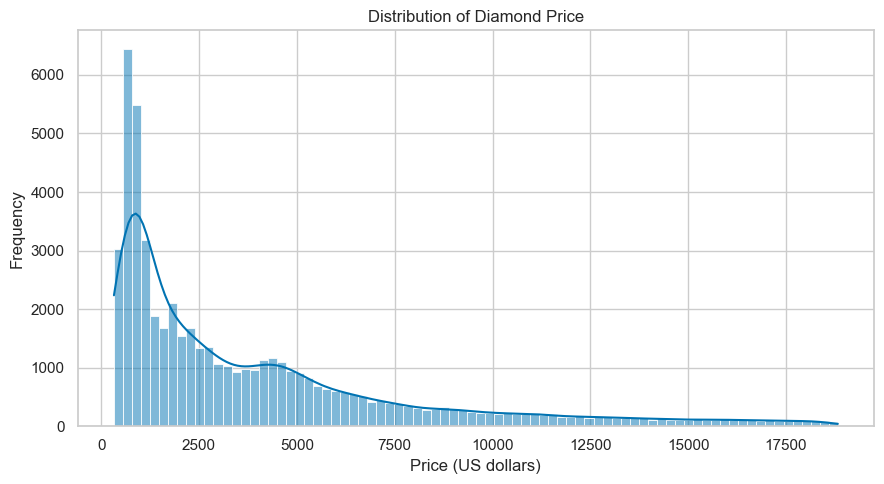

In [4]:
target = "Price(in US dollars)"
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

plt.figure(figsize=(9, 5))
sns.histplot(df[target], kde=True)
plt.title("Distribution of Diamond Price")
plt.xlabel("Price (US dollars)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Observation — target distribution:** The price distribution is strongly right-skewed. Most diamonds are concentrated in the lower and middle price ranges, while a smaller number of diamonds have much higher prices. The long upper tail shows that the dataset contains a relatively small group of expensive diamonds.


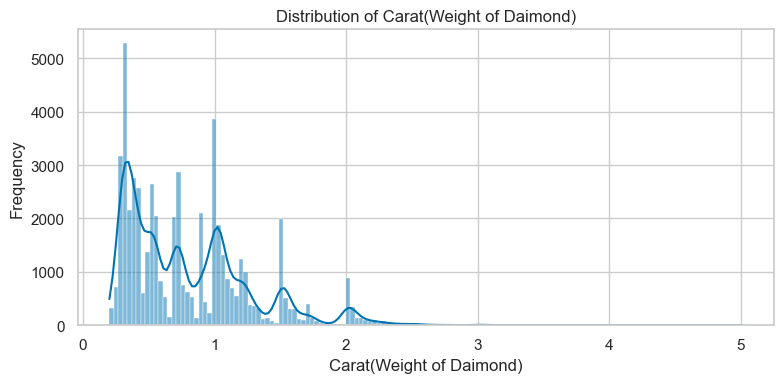

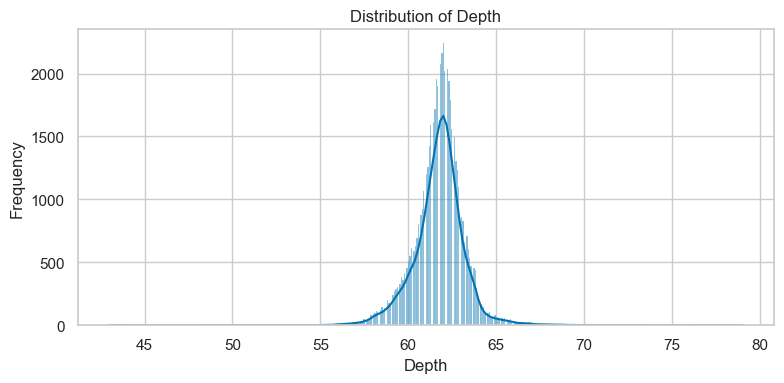

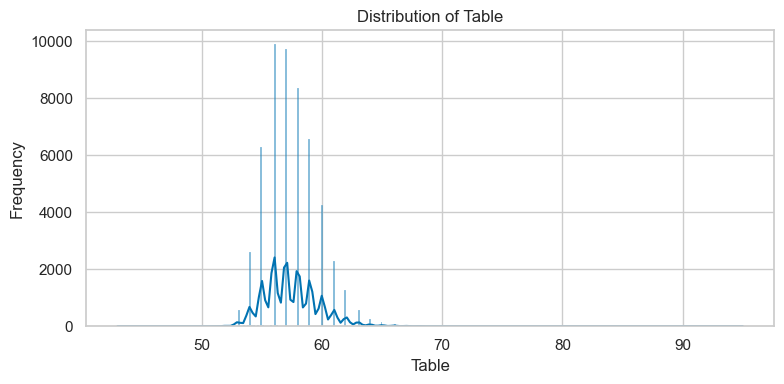

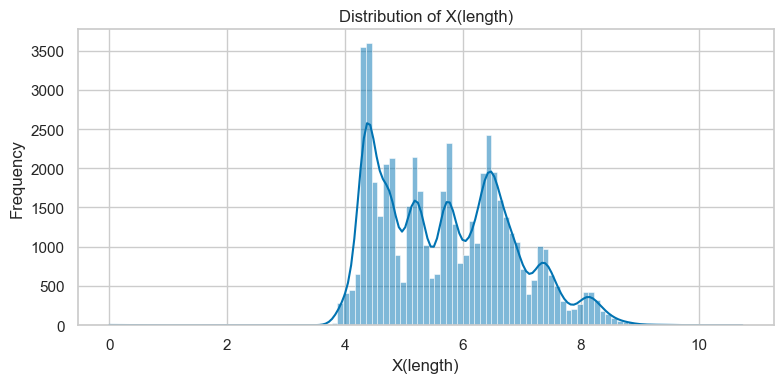

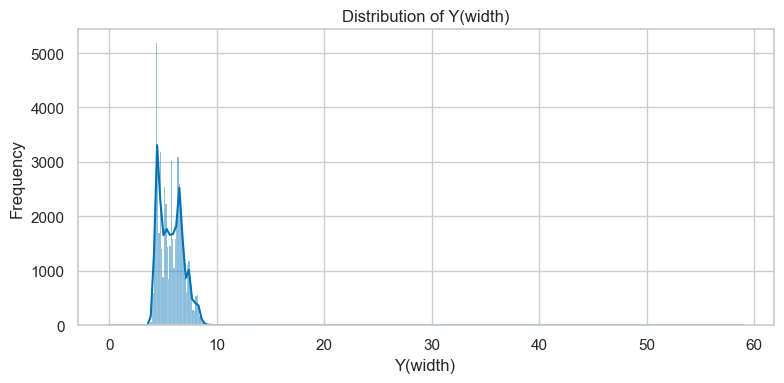

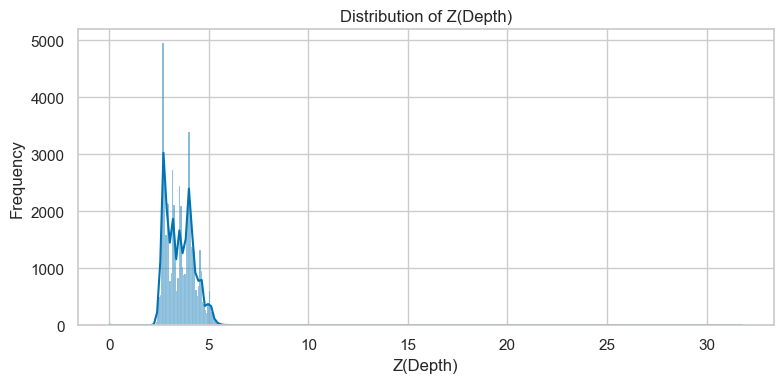

In [5]:
for col in numeric_cols:
    if col == target:
        continue
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

**Observation — numerical feature distributions:** `Carat(Weight of Daimond)` is concentrated at smaller carat values, with fewer large diamonds. `Depth` is concentrated around its middle range, while `Table` is also concentrated within a relatively narrow range. `X(length)`, `Y(width)`, and `Z(Depth)` are mostly concentrated at smaller dimensions but contain some extreme values. The features therefore have different distributions and scales, which is considered during preprocessing.


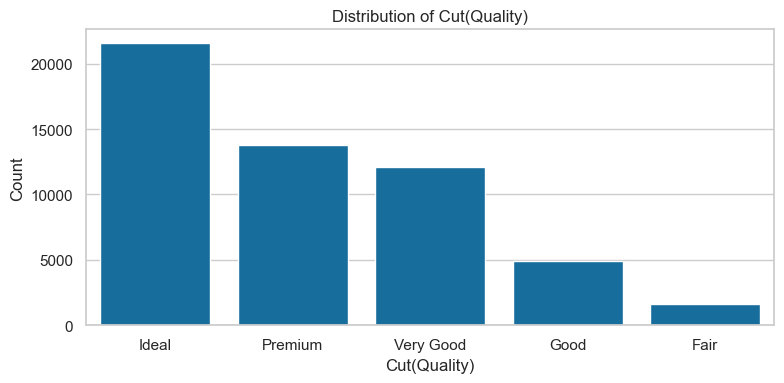

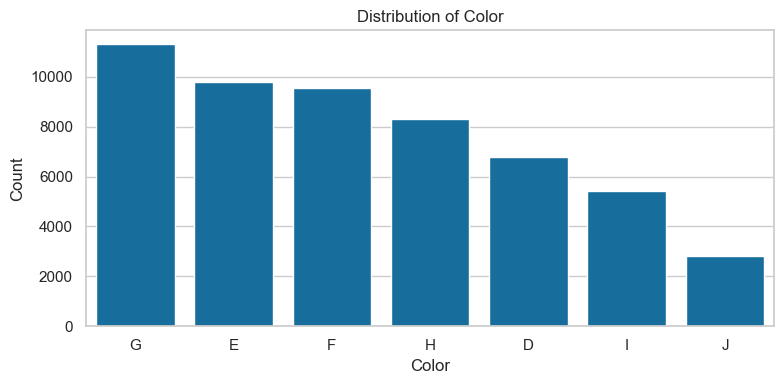

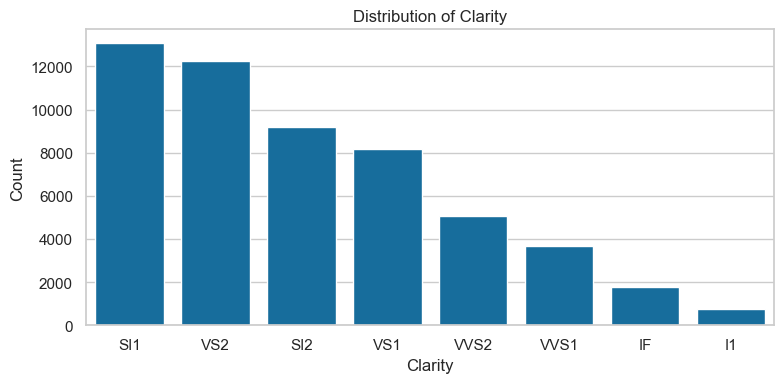

In [6]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

**Observation — categorical distributions:** `Cut(Quality)` is dominated by `Ideal`, followed by `Premium` and `Very Good`, while `Fair` is the least frequent. In `Color`, `G` is the most frequent and `J` is the least frequent. For `Clarity`, `SI1` and `VS2` are the most common categories, while `I1` is the least common. The categories are unevenly distributed but all contain enough observations to be retained for modelling.


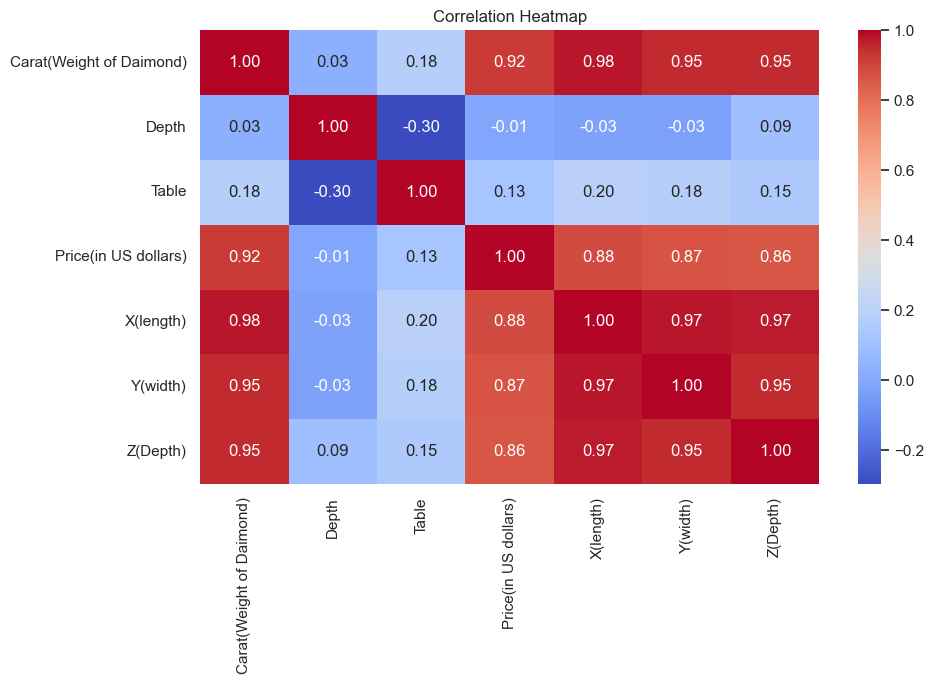

In [7]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Observation — correlation heatmap:** `Carat(Weight of Daimond)` has the strongest positive correlation with price (about 0.92). `X(length)`, `Y(width)`, and `Z(Depth)` also have strong positive correlations with price. `Table` has only a weak positive relationship with price, while `Depth` has almost no linear correlation with price. Carat and the physical dimensions are also strongly correlated with one another, showing that they describe related aspects of diamond size.


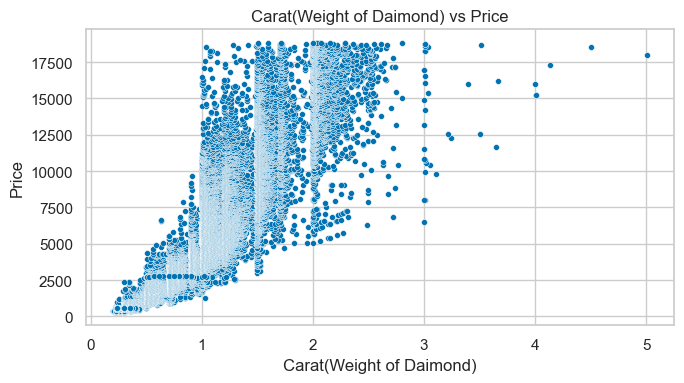

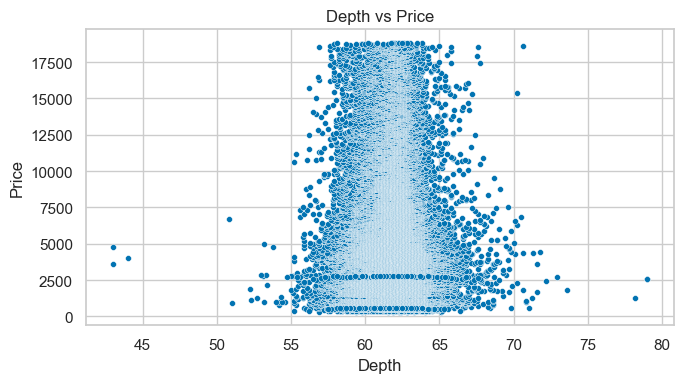

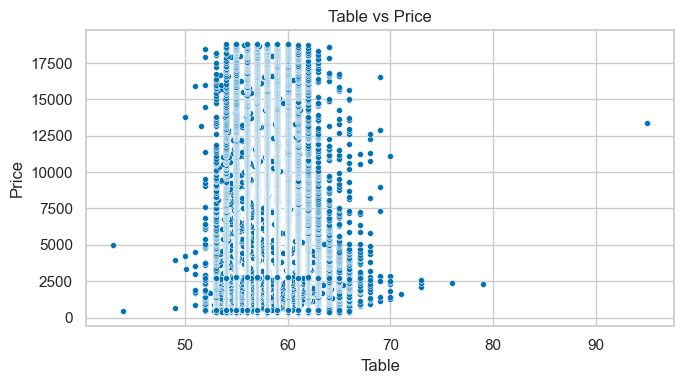

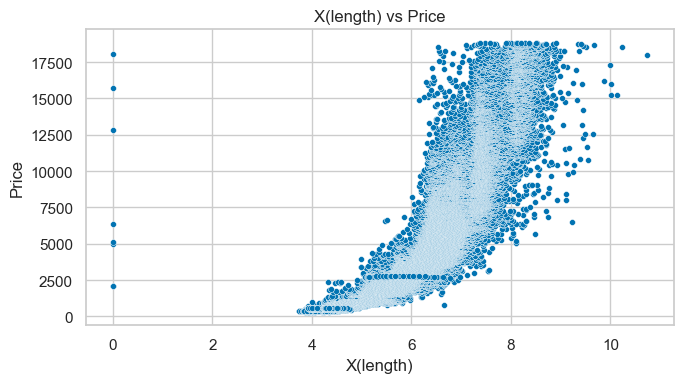

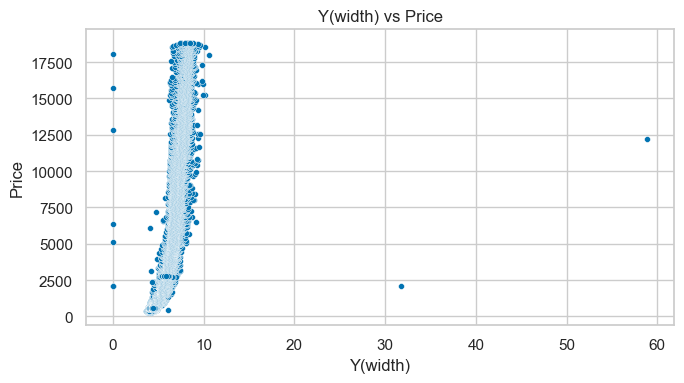

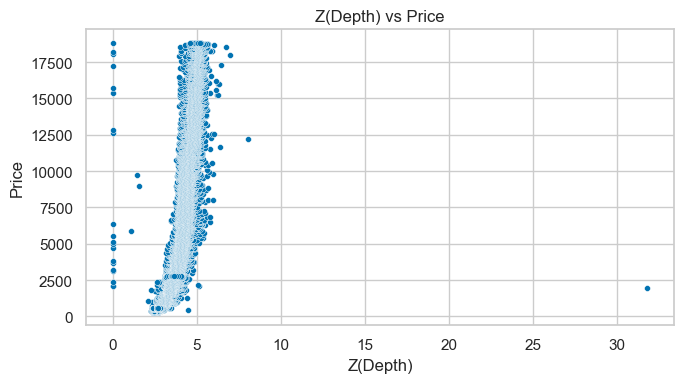

In [8]:
scatter_cols = ["Carat(Weight of Daimond)", "Depth", "Table", "X(length)", "Y(width)", "Z(Depth)"]

for col in scatter_cols:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(data=df, x=col, y=target, s=18)
    plt.title(f"{col} vs Price")
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.tight_layout()
    plt.show()

**Observation — feature vs price relationships:** The `Carat(Weight of Daimond)` plot shows the clearest positive relationship with price, with higher-carat diamonds generally having higher prices. `X(length)`, `Y(width)`, and `Z(Depth)` also show positive relationships with price, although the points become more spread out at larger values. `Depth` and `Table` show much weaker relationships with price. The plots also show a small number of extreme observations at higher values.


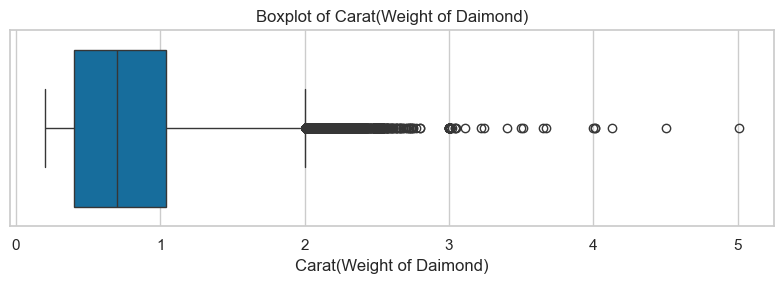

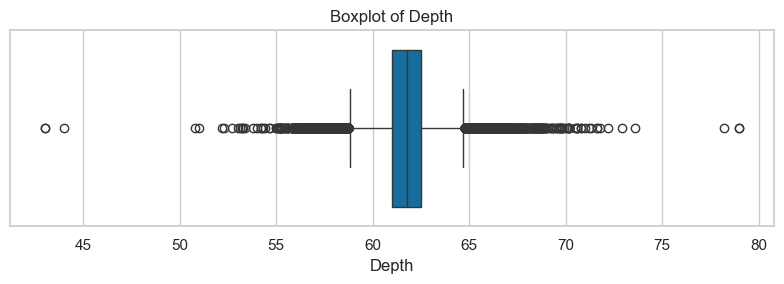

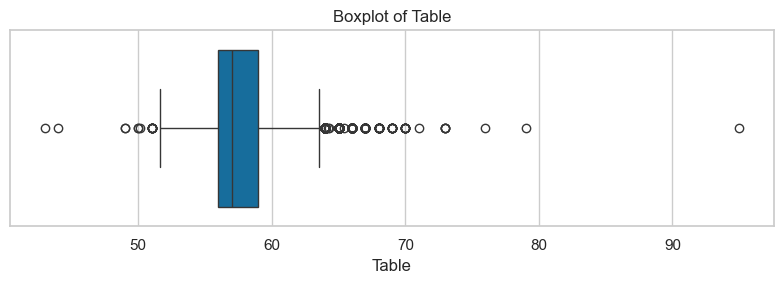

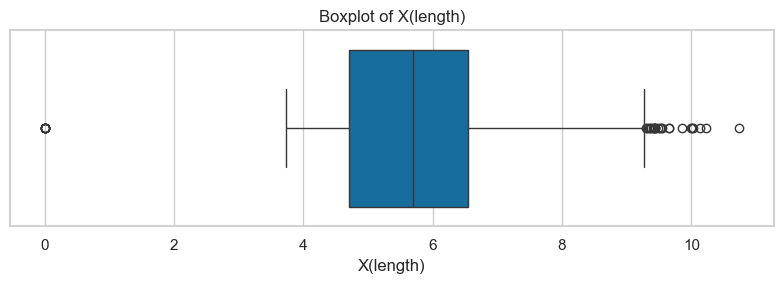

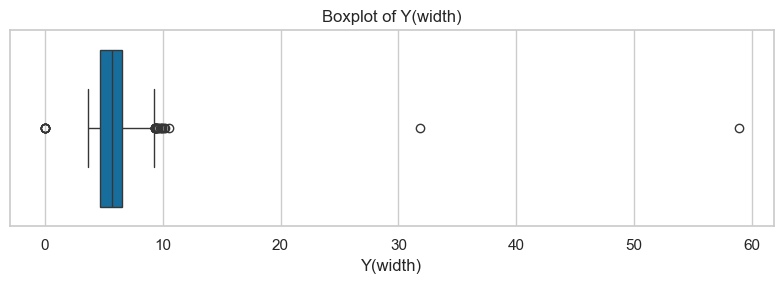

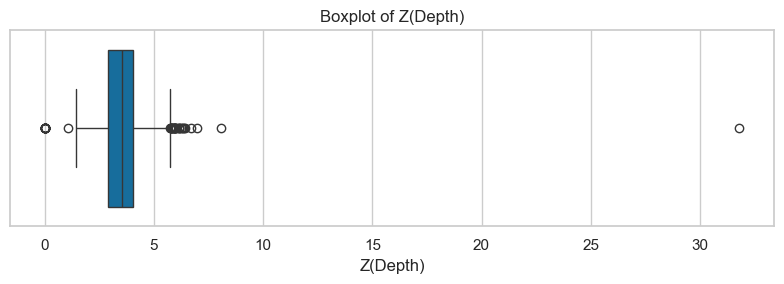

In [9]:
for col in numeric_cols:
    if col == target:
        continue
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

**Observation — outlier visualization:** The boxplots show potential outliers across several numerical variables. `Carat(Weight of Daimond)`, `Depth`, and `Table` contain noticeable values outside their main distributions, while the physical dimensions also contain a small number of extreme observations. These values are checked using the IQR method. Zero values in the physical dimensions are treated as invalid measurements rather than genuine diamond dimensions.


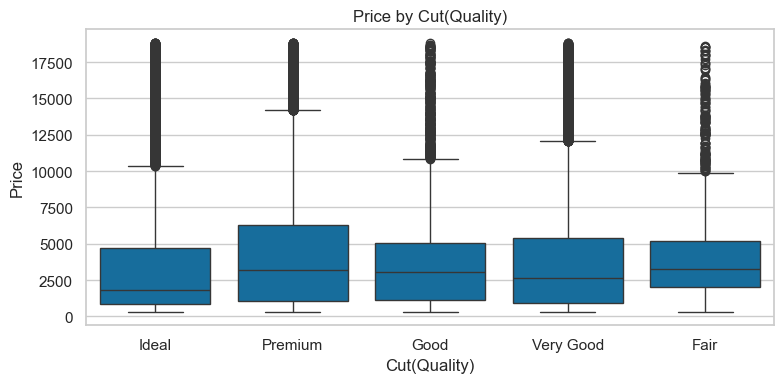

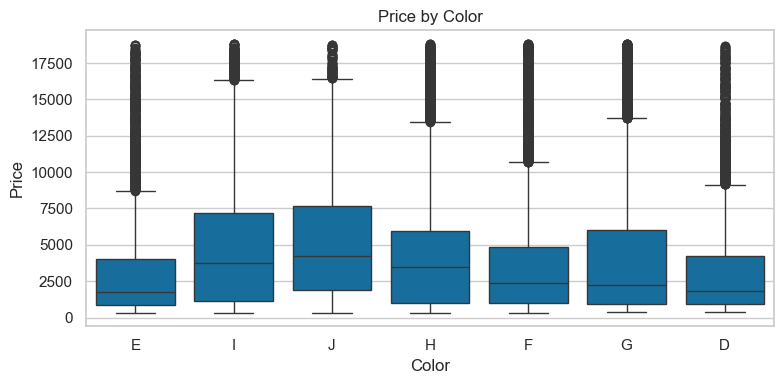

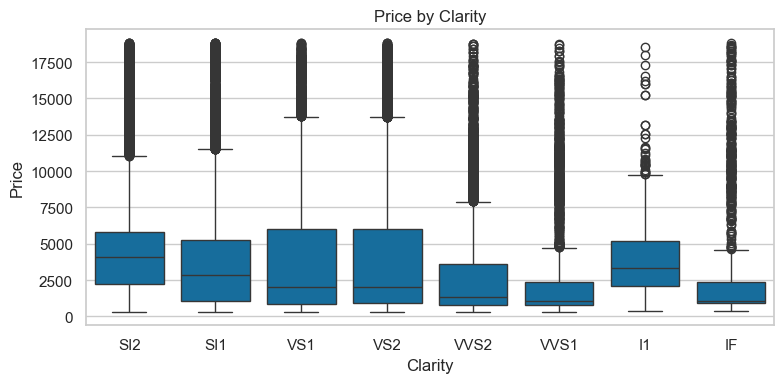

In [10]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col, y=target)
    plt.title(f"Price by {col}")
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.tight_layout()
    plt.show()

**Observation — price by categorical features:** The boxplots show differences in price distributions across the categories of `Cut(Quality)`, `Color`, and `Clarity`. The category distributions overlap, but their medians and spreads are not the same. In particular, price varies noticeably across the different color and clarity levels. This indicates that the categorical features contain useful information for predicting diamond price.


## Outlier Visualization — Boxplots
The boxplots below make the spread and potential extreme values of the numerical predictors explicit before the cleaning step.

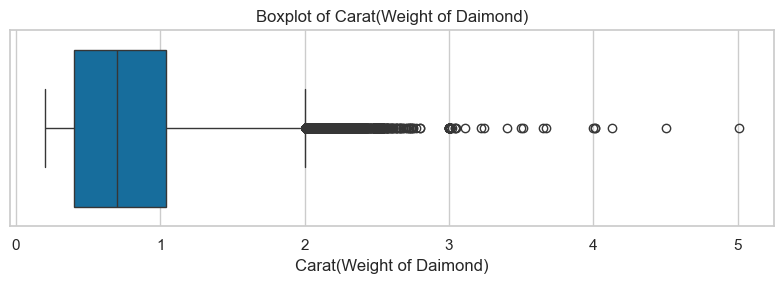

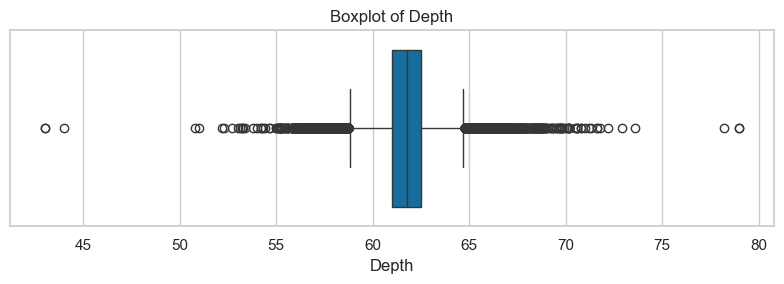

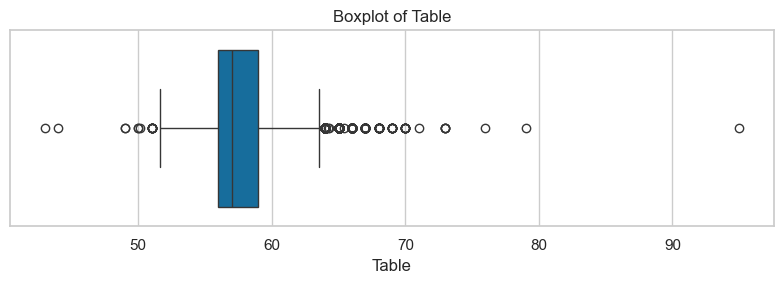

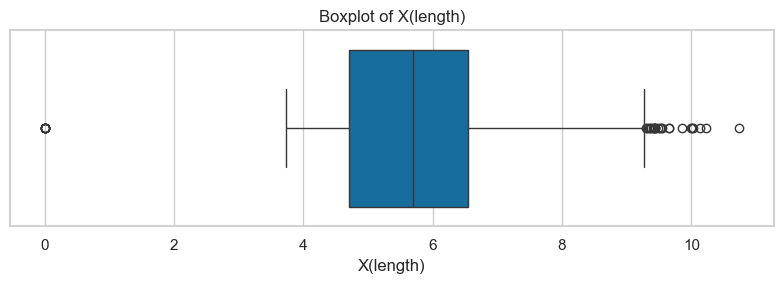

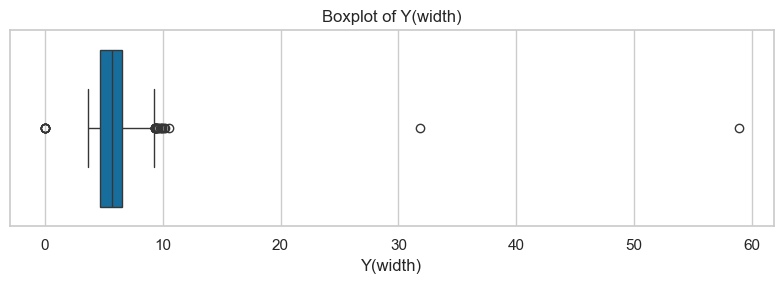

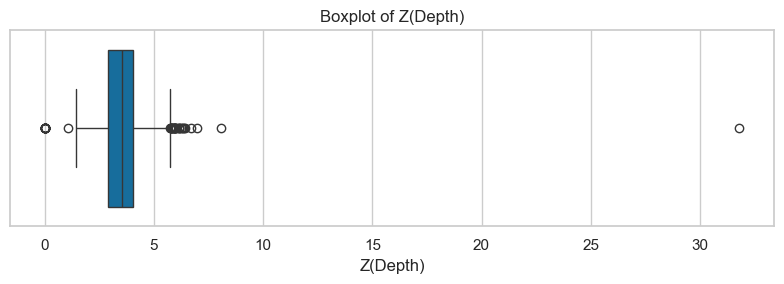

In [9]:
for col in numeric_cols:
    if col == target:
        continue
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

## 3. Data Cleaning and Feature Engineering

In [11]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicate rows removed:", before - len(df))

dimension_cols = ["X(length)", "Y(width)", "Z(Depth)"]

for col in dimension_cols:
    df.loc[df[col] == 0, col] = np.nan

print("\nMissing values after invalid dimensions:")
print(df.isnull().sum())

Duplicate rows removed: 146

Missing values after invalid dimensions:
Carat(Weight of Daimond)     0
Cut(Quality)                 0
Color                        0
Clarity                      0
Depth                        0
Table                        0
Price(in US dollars)         0
X(length)                    7
Y(width)                     6
Z(Depth)                    19
dtype: int64


In [12]:
outlier_rows = []

predictor_numeric = [
    c for c in df.select_dtypes(include=np.number).columns
    if c != target
]

for col in predictor_numeric:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_rows.append([col, count, lower, upper])

outlier_df = pd.DataFrame(
    outlier_rows,
    columns=["Feature", "Outliers", "Lower", "Upper"]
)
outlier_df

,Feature,Outliers,Lower,Upper
0,Carat(Weight of Daimond),1873,-0.560,2.000
1,Depth,2525,58.750,64.750
2,Table,604,51.500,63.500
3,X(length),24,1.965,9.285
4,Y(width),22,1.990,9.270
5,Z(Depth),29,1.230,5.710


In [13]:
df["Volume"] = df["X(length)"] * df["Y(width)"] * df["Z(Depth)"]
df.loc[df["Volume"] <= 0, "Volume"] = np.nan

print("Features after engineering:")
print(df.columns.tolist())

Features after engineering:
['Carat(Weight of Daimond)', 'Cut(Quality)', 'Color', 'Clarity', 'Depth', 'Table', 'Price(in US dollars)', 'X(length)', 'Y(width)', 'Z(Depth)', 'Volume']


### B3. Feature engineering justification

`Volume = X × Y × Z` is added to represent the overall physical size of the diamond. This combines the three measured dimensions into a single size-related feature and may help the models capture the relationship between diamond size and price more directly.


## 4. Train-Test Split and Preprocessing

In [14]:
X = df.drop(columns=[target])
y = df[target]

price_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=price_bins
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (43035, 10)
Test set: (10759, 10)


In [15]:
clip_cols = [
    "Carat(Weight of Daimond)", "Depth", "Table",
    "X(length)", "Y(width)", "Z(Depth)", "Volume"
]

def fit_iqr_bounds(data, columns):
    bounds = {}
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        bounds[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return bounds

def apply_iqr_bounds(data, bounds):
    data = data.copy()
    for col, (lower, upper) in bounds.items():
        data[col] = data[col].clip(lower, upper)
    return data

iqr_bounds = fit_iqr_bounds(X_train, clip_cols)
X_train = apply_iqr_bounds(X_train, iqr_bounds)
X_test = apply_iqr_bounds(X_test, iqr_bounds)

In [16]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", encoder)
    ]), categorical_features)
])

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print("Processed training shape:", X_train_p.shape)
print("Processed test shape:", X_test_p.shape)

Processed training shape: (43035, 27)
Processed test shape: (10759, 27)


## 5. Regression Models

In [17]:
results = []
fitted_models = {}
predictions = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    results.append({
        "Model": name,
        "R2": r2_score(y_te, pred),
        "RMSE": np.sqrt(mean_squared_error(y_te, pred)),
        "MAE": mean_absolute_error(y_te, pred)
    })

    fitted_models[name] = model
    predictions[name] = pred

In [18]:
# 1. Linear Regression
evaluate_model(
    "Linear Regression",
    LinearRegression(),
    X_train_p, y_train, X_test_p, y_test
)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": fitted_models["Linear Regression"].coef_
})
coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()
coef_df.sort_values("Absolute Coefficient", ascending=False).head(15)

,Feature,Coefficient,Absolute Coefficient
0,num__Carat(Weight of Daimond),3518.618148,3518.618148
6,num__Volume,3218.889982,3218.889982
19,cat__Clarity_I1,-3203.799755,3203.799755
5,num__Z(Depth),-2413.929985,2413.929985
18,cat__Color_J,-1474.421040,1474.421040
20,cat__Clarity_IF,1431.920393,1431.920393
3,num__X(length),-1271.995357,1271.995357
22,cat__Clarity_SI2,-1126.882881,1126.882881
25,cat__Clarity_VVS1,1084.964470,1084.964470
4,num__Y(width),1076.226052,1076.226052


Positive coefficients indicate a positive relationship with price in the standardized linear model; negative coefficients indicate a negative relationship.

In [19]:
# 2. Ridge Regression
ridge = Ridge(alpha=1.0)
evaluate_model("Ridge Regression", ridge, X_train_p, y_train, X_test_p, y_test)

In [20]:
# 3. Lasso Regression
lasso = Lasso(alpha=0.1, max_iter=10000, random_state=RANDOM_STATE)
evaluate_model("Lasso Regression", lasso, X_train_p, y_train, X_test_p, y_test)

zero_coefficients = np.sum(lasso.coef_ == 0)
print("Zero Lasso coefficients:", zero_coefficients)

Zero Lasso coefficients: 2


In [21]:
# 4. Elastic Net
elastic = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    max_iter=10000,
    random_state=RANDOM_STATE
)
evaluate_model(
    "ElasticNet Regression",
    elastic,
    X_train_p, y_train, X_test_p, y_test
)

In [22]:
# 5. Polynomial Regression
# Use the same fully preprocessed feature set as the other regression models,
# including one-hot encoded categorical features.
X_poly_train, X_poly_val, y_poly_train, y_poly_val = train_test_split(
    X_train_p,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE
)

poly_scores = {}

for degree in [1, 2, 3]:
    poly = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linear", LinearRegression())
    ])
    poly.fit(X_poly_train, y_poly_train)
    pred = poly.predict(X_poly_val)
    poly_scores[degree] = r2_score(y_poly_val, pred)

print("Validation R²:", poly_scores)

best_degree = max(poly_scores, key=poly_scores.get)

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("linear", LinearRegression())
])
poly_model.fit(X_train_p, y_train)
poly_pred = poly_model.predict(X_test_p)

results.append({
    "Model": f"Polynomial Regression (Degree {best_degree})",
    "R2": r2_score(y_test, poly_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, poly_pred)),
    "MAE": mean_absolute_error(y_test, poly_pred)
})
fitted_models[f"Polynomial Regression (Degree {best_degree})"] = poly_model
predictions[f"Polynomial Regression (Degree {best_degree})"] = poly_pred

print("Selected degree:", best_degree)

Validation R²: {1: 0.92650711173097, 2: 0.972736900609005, 3: 0.8919186060227325}
Selected degree: 2


In [23]:
# 6. Decision Tree Regressor
evaluate_model(
    "Decision Tree Regressor",
    DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    ),
    X_train_p, y_train, X_test_p, y_test
)

In [24]:
# 7. Random Forest Regressor
evaluate_model(
    "Random Forest Regressor",
    RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    X_train_p, y_train, X_test_p, y_test
)

In [25]:
# 8. Gradient Boosting Regressor
evaluate_model(
    "Gradient Boosting Regressor",
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),
    X_train_p, y_train, X_test_p, y_test
)

In [26]:
# 9. Support Vector Regressor
evaluate_model(
    "Support Vector Regressor",
    SVR(kernel="linear", C=10),
    X_train_p, y_train, X_test_p, y_test
)

In [27]:
# 10. KNN Regressor
evaluate_model(
    "KNN Regressor",
    KNeighborsRegressor(n_neighbors=15, weights="distance"),
    X_train_p, y_train, X_test_p, y_test
)

## 6. Model Comparison

In [28]:
results_df = (
    pd.DataFrame(results)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

results_df.index = results_df.index + 1
results_df

,Model,R2,RMSE,MAE
1,Random Forest Regressor,0.977778,595.835174,308.906055
2,Polynomial Regression (Degree 2),0.972520,662.581323,392.572628
3,KNN Regressor,0.965093,746.777871,376.490878
4,Decision Tree Regressor,0.964012,758.251026,403.707826
5,Gradient Boosting Regressor,0.948240,909.349412,509.131739
6,Linear Regression,0.928034,1072.255018,708.097788
7,Ridge Regression,0.928030,1072.281939,708.020664
8,Lasso Regression,0.928029,1072.292697,707.715904
9,Support Vector Regressor,0.911634,1188.160899,629.124490
10,ElasticNet Regression,0.896144,1288.098746,861.201269


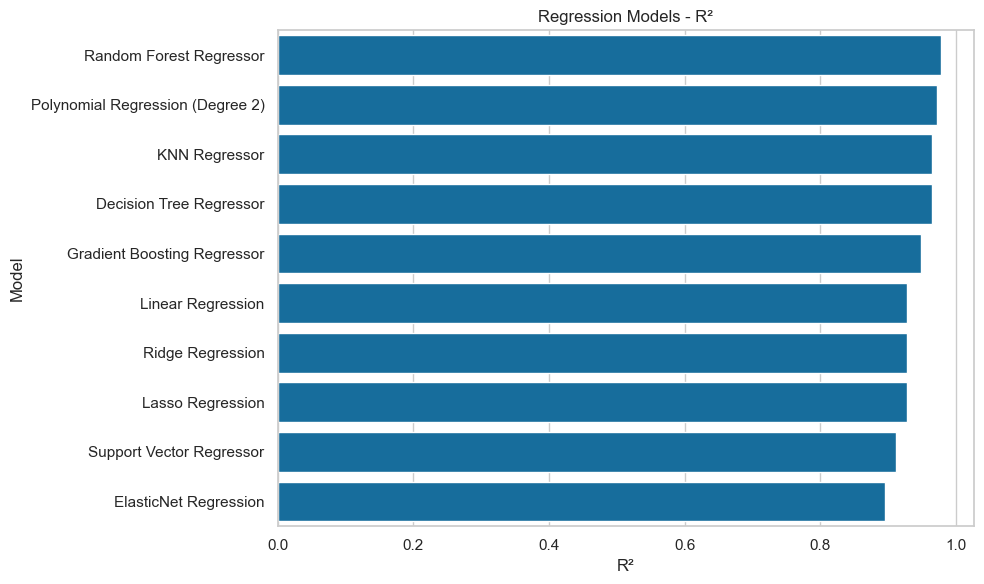

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="R2", y="Model")
plt.title("Regression Models - R²")
plt.xlabel("R²")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

**Observation — model comparison:** The models show clear differences in predictive performance on the same held-out test set. The tree-based ensemble models capture the non-linear relationships in the data better than the simpler linear models, while the linear models provide a useful baseline. The ranking is based on R², with RMSE and MAE used alongside it to compare prediction error.


## 7. Hyperparameter Tuning

In [30]:
ridge_grid = GridSearchCV(
    Ridge(),
    {"alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100, 200]},
    cv=3,
    scoring="r2",
    n_jobs=-1
)
ridge_grid.fit(X_train_p, y_train)

ridge_tuned_pred = ridge_grid.predict(X_test_p)
ridge_base_r2 = results_df.loc[
    results_df["Model"] == "Ridge Regression", "R2"
].iloc[0]
ridge_tuned_r2 = r2_score(y_test, ridge_tuned_pred)

ridge_base_cv = cross_val_score(
    Ridge(alpha=1.0), X_train_p, y_train, cv=3, scoring="r2", n_jobs=-1
)

print("Ridge best parameters:", ridge_grid.best_params_)
print(f"Ridge baseline test R²: {ridge_base_r2:.6f}")
print(f"Ridge tuned test R²: {ridge_tuned_r2:.6f}")
print(f"Test-set improvement: {ridge_tuned_r2 - ridge_base_r2:+.6f}")
print(f"Ridge baseline CV R²: {ridge_base_cv.mean():.6f}")
print(f"Ridge tuned CV R²: {ridge_grid.best_score_:.6f}")
print(f"CV improvement: {ridge_grid.best_score_ - ridge_base_cv.mean():+.6f}")


Ridge best parameters: {'alpha': 10}
Ridge baseline test R²: 0.928030
Ridge tuned test R²: 0.927986
Test-set improvement: -0.000045
Ridge baseline CV R²: 0.927211
Ridge tuned CV R²: 0.927213
CV improvement: +0.000002


In [31]:
rf_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    {
        "n_estimators": [50, 100, 200],
        "max_depth": [8, 12, 16, None],
        "min_samples_leaf": [1, 2, 4]
    },
    cv=3,
    scoring="r2",
    n_jobs=-1
)
rf_grid.fit(X_train_p, y_train)

rf_tuned_pred = rf_grid.predict(X_test_p)
rf_base_r2 = results_df.loc[
    results_df["Model"] == "Random Forest Regressor", "R2"
].iloc[0]
rf_tuned_r2 = r2_score(y_test, rf_tuned_pred)

rf_base_cv = cross_val_score(
    RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    X_train_p,
    y_train,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

print("Random Forest best parameters:", rf_grid.best_params_)
print(f"Random Forest baseline test R²: {rf_base_r2:.6f}")
print(f"Random Forest tuned test R²: {rf_tuned_r2:.6f}")
print(f"Test-set improvement: {rf_tuned_r2 - rf_base_r2:+.6f}")
print(f"Random Forest baseline CV R²: {rf_base_cv.mean():.6f}")
print(f"Random Forest tuned CV R²: {rf_grid.best_score_:.6f}")
print(f"CV improvement: {rf_grid.best_score_ - rf_base_cv.mean():+.6f}")


Random Forest best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Random Forest baseline test R²: 0.977778
Random Forest tuned test R²: 0.980482
Test-set improvement: +0.002704
Random Forest baseline CV R²: 0.976917
Random Forest tuned CV R²: 0.979778
CV improvement: +0.002861


In [32]:
# Additional parameter checks
lasso_scores = {}
for alpha in [0.001, 0.01, 0.1]:
    model = Lasso(alpha=alpha, max_iter=100000, random_state=RANDOM_STATE)
    model.fit(X_train_p, y_train)
    lasso_scores[alpha] = r2_score(y_test, model.predict(X_test_p))

elastic_scores = {}
for ratio in [0.2, 0.5, 0.8]:
    model = ElasticNet(
        alpha=0.1,
        l1_ratio=ratio,
        max_iter=100000,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_p, y_train)
    elastic_scores[ratio] = r2_score(y_test, model.predict(X_test_p))

tree_scores = {}
for depth in [5, 10, 15]:
    model = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train_p, y_train)
    tree_scores[depth] = r2_score(y_test, model.predict(X_test_p))

gb_scores = {}
for lr in [0.03, 0.05, 0.1]:
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=lr,
        max_depth=3,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_p, y_train)
    gb_scores[lr] = r2_score(y_test, model.predict(X_test_p))

knn_scores = {}
for k in [5, 10, 15]:
    model = KNeighborsRegressor(n_neighbors=k, weights="distance")
    model.fit(X_train_p, y_train)
    knn_scores[k] = r2_score(y_test, model.predict(X_test_p))

print("Lasso alpha:", lasso_scores)
print("ElasticNet l1_ratio:", elastic_scores)
print("Decision Tree max_depth:", tree_scores)
print("Gradient Boosting learning_rate:", gb_scores)
print("KNN k:", knn_scores)

Lasso alpha: {0.001: 0.928033658772459, 0.01: 0.9280332911882576, 0.1: 0.9280286492798846}
ElasticNet l1_ratio: {0.2: 0.8836220563067303, 0.5: 0.8961440765075606, 0.8: 0.9145108712986525}
Decision Tree max_depth: {5: 0.9124046925455749, 10: 0.963005602989576, 15: 0.9690487085985235}
Gradient Boosting learning_rate: {0.03: 0.9245152670001272, 0.05: 0.9482399678242242, 0.1: 0.9674679207441321}
KNN k: {5: 0.9672459169087643, 10: 0.9668277854056341, 15: 0.9650927338825633}


In [33]:
# SVR kernel and C check on a smaller training sample
sample_size = min(5000, len(X_train_p))
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(X_train_p), sample_size, replace=False)

X_svr_train, X_svr_val, y_svr_train, y_svr_val = train_test_split(
    X_train_p[idx],
    y_train.iloc[idx],
    test_size=0.20,
    random_state=RANDOM_STATE
)

svr_scores = {}

for kernel in ["linear", "rbf"]:
    for c in [1, 10]:
        model = SVR(kernel=kernel, C=c)
        model.fit(X_svr_train, y_svr_train)
        svr_scores[(kernel, c)] = r2_score(
            y_svr_val, model.predict(X_svr_val)
        )

svr_scores

{('linear', 1): 0.7346508412831321,
 ('linear', 10): 0.8693747757964884,
 ('rbf', 1): -0.015551829507226778,
 ('rbf', 10): 0.45775919770644835}

## 8. Five-Fold Cross-Validation

In [34]:
top2 = results_df.head(2)["Model"].tolist()

for name in top2:
    if name.startswith("Polynomial Regression"):
        degree = int(re.search(r"Degree (\d+)", name).group(1))
        cv_model = Pipeline([
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("linear", LinearRegression())
        ])
        scores = cross_val_score(
            cv_model,
            X_train_p,
            y_train,
            cv=5,
            scoring="r2",
            n_jobs=-1
        )
    else:
        scores = cross_val_score(
            fitted_models[name],
            X_train_p,
            y_train,
            cv=5,
            scoring="r2",
            n_jobs=-1
        )

    print(f"{name}: Mean R² = {scores.mean():.4f}, Std = {scores.std():.4f}")

Random Forest Regressor: Mean R² = 0.9774, Std = 0.0004
Polynomial Regression (Degree 2): Mean R² = 0.9707, Std = 0.0025


## 9. Regression Diagnostics

In [35]:
best_model_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_model_name]
residuals = y_test - best_pred

print("Best model:", best_model_name)
print(f"R²: {r2_score(y_test, best_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, best_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, best_pred):.4f}")

Best model: Random Forest Regressor
R²: 0.9778
RMSE: 595.8352
MAE: 308.9061


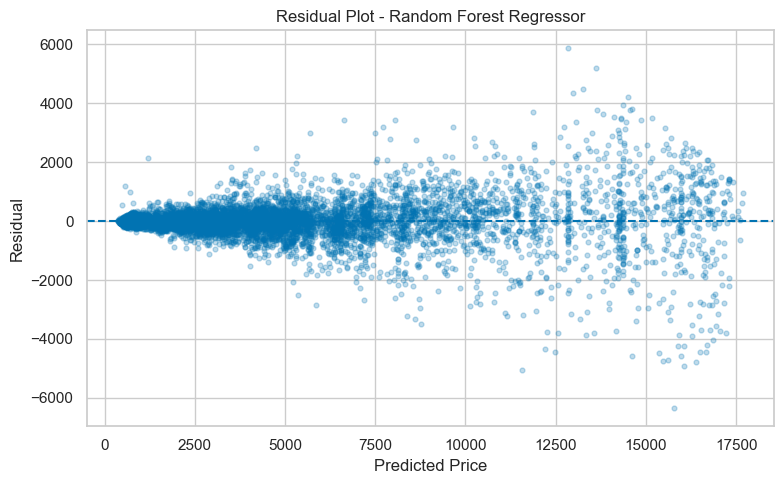

In [36]:
plt.figure(figsize=(8, 5))
plt.scatter(best_pred, residuals, alpha=0.25, s=12)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title(f"Residual Plot - {best_model_name}")
plt.tight_layout()
plt.show()

**Observation — residual plot:** The residuals are centered around the zero line for most observations, while a smaller number of points show larger positive or negative errors. The spread is wider for some higher-priced diamonds, showing that the model does not predict every extreme value equally well.


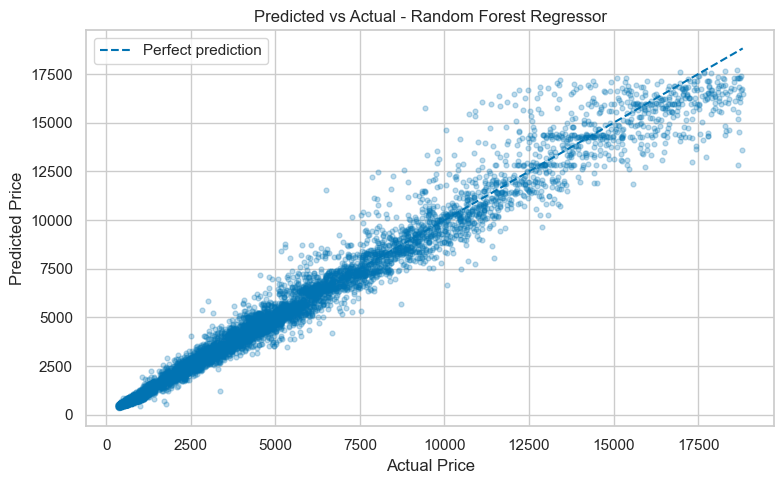

In [37]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, best_pred, alpha=0.25, s=12)

lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, linestyle="--", label="Perfect prediction")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Predicted vs Actual - {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

**Observation — predicted vs actual:** Most predicted values lie close to the diagonal perfect-prediction line, showing good agreement between actual and predicted prices. The largest deviations occur for some higher-priced diamonds, where the prediction error is larger.


## 10. Feature Importance


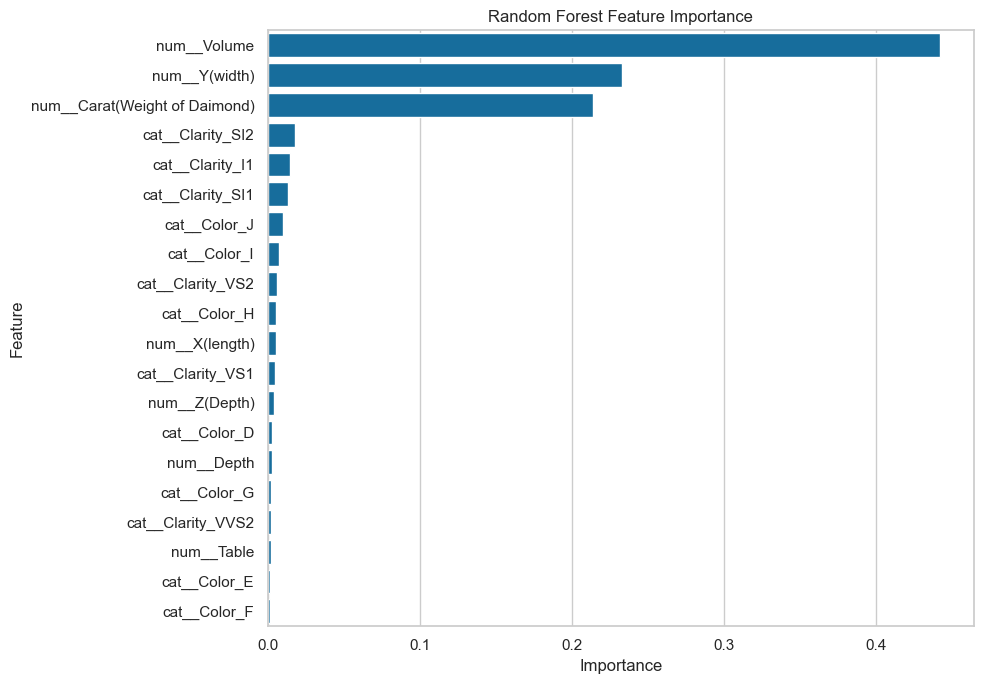

num__Volume                      0.441999
num__Y(width)                    0.232672
num__Carat(Weight of Daimond)    0.213887
cat__Clarity_SI2                 0.018377
cat__Clarity_I1                  0.014740
cat__Clarity_SI1                 0.013713
cat__Color_J                     0.009978
cat__Color_I                     0.007426
cat__Clarity_VS2                 0.006311
cat__Color_H                     0.005754
num__X(length)                   0.005649
cat__Clarity_VS1                 0.005230
num__Z(Depth)                    0.004423
cat__Color_D                     0.002688
num__Depth                       0.002678
cat__Color_G                     0.002423
cat__Clarity_VVS2                0.002396
num__Table                       0.002110
cat__Color_E                     0.001682
cat__Color_F                     0.001431
dtype: float64

In [38]:
rf_best = rf_grid.best_estimator_

importance = pd.Series(
    rf_best.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

importance

**Observation — feature importance:** The Random Forest feature-importance plot shows that the model relies most on the size-related numerical features and their encoded representations. The importance values are concentrated in a smaller group of features, while several other features contribute less individually. These values describe the model's predictive use of the features and do not represent causation.


## 11. Conclusion

The analysis of the Diamond Price dataset gives the following conclusions:

- The target price is strongly right-skewed, with most diamonds in the lower and middle price ranges and a smaller number of high-priced diamonds.
- `Carat(Weight of Daimond)` has the strongest linear relationship with price, followed by the physical dimensions `X(length)`, `Y(width)`, and `Z(Depth)`.
- `Depth` and `Table` have weaker direct relationships with price, but they are still retained as potential predictors.
- The categorical variables `Cut(Quality)`, `Color`, and `Clarity` show differences in price distributions and provide additional information for prediction.
- Duplicate rows, invalid zero dimensions, and numerical outliers were identified and treated before model training.
- `Volume = X × Y × Z` was created to represent the overall physical size of a diamond.
- Categorical variables were one-hot encoded and numerical variables were imputed and scaled using the training data only.
- The ten regression models show different levels of performance, confirming that model choice affects prediction accuracy for this dataset.
- The final model comparison, residual analysis, predicted-vs-actual plot, and feature-importance plot were used to assess the regression performance and understand the main predictors of diamond price.
